In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from numpy.lib.stride_tricks import sliding_window_view

In [82]:
def inicializar_imagem():
    cap = cv2.VideoCapture('dataset/clipe.mp4')

    if not cap.isOpened():
        print("Erro ao abrir o arquivo de vídeo.")
    
    return cap

Diferenças entre pixels

[39, 40, 43, 47, 51, 52, 53, 54, 55, 56, 57, 58, 59, 61, 63, 64, 65, 67, 71, 75, 79, 83, 87, 91, 95, 97, 99, 103, 107]


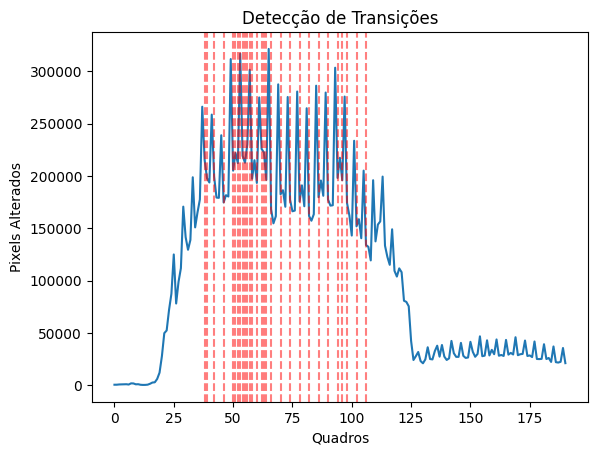

In [83]:
cap = inicializar_imagem()

quadro_anterior = None

metricas = []
indices = []

T1 = 10 
T2 = 200000

transicoes = cv2.VideoWriter('transicoes/transicoes_pixels.mp4', cv2.VideoWriter_fourcc(*'mp4v'), cap.get(cv2.CAP_PROP_FPS), (int(cap.get(cv2.CAP_PROP_FRAME_WIDTH)), int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))))

# 2. Loop de leitura do vídeo
while cap.isOpened():
    
    ret, frame = cap.read()
    
    
    if not ret:
        break
        
    quadro_cinza = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    

    if quadro_anterior is not None:
        dif = cv2.absdiff(quadro_cinza, quadro_anterior)

        qntd = np.sum(dif > T1)

        metricas.append(qntd)

        if qntd > T2:
            indices.append(int(cap.get(cv2.CAP_PROP_POS_FRAMES)))
            transicoes.write(frame)

        pass
        
    
    quadro_anterior = quadro_cinza

cap.release()
cv2.destroyAllWindows()
transicoes.release()

print(indices)
plt.plot(metricas, label='Métrica de Diferença')

# Desenha uma linha vermelha tracejada para cada transição detectada
for idx in indices:
    # Subtraímos 2 porque a lista 'metricas' começou a ser preenchida a partir do 2º quadro
    plt.axvline(x=idx - 1, color='red', linestyle='--', alpha=0.5)

plt.title('Detecção de Transições')
plt.xlabel('Quadros')
plt.ylabel('Pixels Alterados')
plt.show()



Diferença entre blocos

[35, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 79, 87, 99, 105, 106, 107, 111, 115]


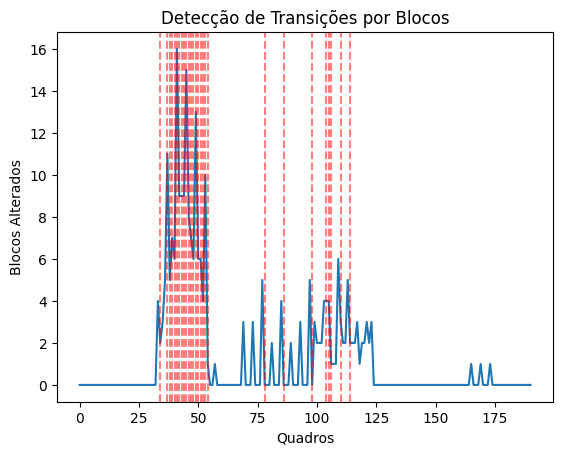

In [84]:
cap = inicializar_imagem()

quadro_anterior = None

metricas = []
indices = []

T1 = 1000
T2 = 4

transicoes = cv2.VideoWriter('transicoes/transicoes_blocos.mp4', cv2.VideoWriter_fourcc(*'mp4v'), cap.get(cv2.CAP_PROP_FPS), (int(cap.get(cv2.CAP_PROP_FRAME_WIDTH)), int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))))

largura, altura = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH)), int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

bloco_h, bloco_w = altura // 8, largura // 8

# 2. Loop de leitura do vídeo
while cap.isOpened():
    
    ret, frame = cap.read()
    qntd = 0
    
    if not ret:
        break
        
    quadro_cinza = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    

    if quadro_anterior is not None:
        lista_blocos = quadro_cinza.reshape(8, bloco_h, 8, bloco_w)
        lista_blocos = lista_blocos.transpose(0, 2, 1, 3).reshape(-1, bloco_h, bloco_w)

        lista_blocos_anterior = quadro_anterior.reshape(8, bloco_h, 8, bloco_w)
        lista_blocos_anterior = lista_blocos_anterior.transpose(0, 2, 1, 3).reshape(-1, bloco_h, bloco_w)

        for i in range(len(lista_blocos)):
            erro = np.mean((lista_blocos[i].astype(int) - lista_blocos_anterior[i].astype(int))**2)

            if (erro > T1):
                qntd += 1

        metricas.append(qntd)

        if qntd >= T2:
            indices.append(int(cap.get(cv2.CAP_PROP_POS_FRAMES)))
            transicoes.write(frame)

        pass
        
    
    quadro_anterior = quadro_cinza

cap.release()
cv2.destroyAllWindows()
transicoes.release()

print(indices)
plt.plot(metricas, label='Métrica de Diferença')

# Desenha uma linha vermelha tracejada para cada transição detectada
for idx in indices:
    # Subtraímos 2 porque a lista 'metricas' começou a ser preenchida a partir do 2º quadro
    plt.axvline(x=idx - 1, color='red', linestyle='--', alpha=0.5)

plt.title('Detecção de Transições por Blocos')
plt.xlabel('Quadros')
plt.ylabel('Blocos Alterados')
plt.show()

Diferença entre histogramas

[120 121 122 123 124 125 126 127 128 132 136]


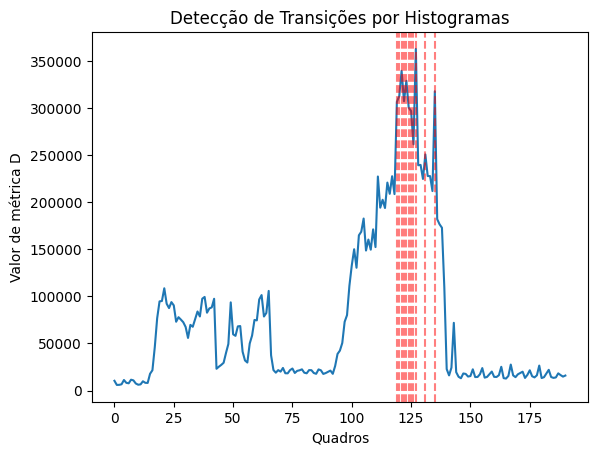

In [85]:
cap = inicializar_imagem()

quadro_anterior = None

metricas = []
indices = []

a = 2

transicoes = cv2.VideoWriter('transicoes/transicoes_hist.mp4', cv2.VideoWriter_fourcc(*'mp4v'), cap.get(cv2.CAP_PROP_FPS), (int(cap.get(cv2.CAP_PROP_FRAME_WIDTH)), int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))))

# 2. Loop de leitura do vídeo
while cap.isOpened():
    
    ret, frame = cap.read()
    
    
    if not ret:
        break
        
    quadro_cinza = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    if quadro_anterior is not None:
        
        hist_quadro = cv2.calcHist([quadro_cinza], channels=[0], mask=None, histSize=[256], ranges=[0, 256])
        hist_quadro_anterior = cv2.calcHist([quadro_anterior], channels=[0], mask=None, histSize=[256], ranges=[0, 256])

        dif = np.abs(hist_quadro - hist_quadro_anterior)
        D = np.sum(dif)

        metricas.append(D)

        pass
        
    
    quadro_anterior = quadro_cinza

cap.release()

T = np.mean(metricas) + a * np.std(metricas)

indices = np.where(np.array(metricas) > T)[0] + 1  # +1 para compensar o início da lista 'metricas'

cap = inicializar_imagem()

contador_frames = 0
while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break
        
    if contador_frames in indices:
        transicoes.write(frame)
        
    contador_frames += 1

cap.release()
cv2.destroyAllWindows()
transicoes.release()

print(indices)
plt.plot(metricas, label='Métrica de Diferença')

# Desenha uma linha vermelha tracejada para cada transição detectada
for idx in indices:
    # Subtraímos 1 porque a lista 'metricas' começou a ser preenchida a partir do 1º quadro
    plt.axvline(x=idx - 1, color='red', linestyle='--', alpha=0.5)

plt.title('Detecção de Transições por Histogramas')
plt.xlabel('Quadros')
plt.ylabel('Valor de métrica D')
plt.show()
